# Лабораторная работа 3: сегментация 8 типов дорожных знаков и трекинг

В этой работе:
- декодируем аннотации из `sign_dataset` в полноценные маски сегментации;
- обучаем предобученную модель сегментации (и при желании вторую для сравнения);
- считаем метрики **IoU, Precision, Recall, L2** на `val`;
- считаем долю изображений с **IoU >= 0.5 / 0.75 / 0.9**;
- готовим пайплайн для видео: сегментация + 2 алгоритма трекинга

Датасет ожидается в структуре:
- `sign_dataset/train/*.jpg` + `sign_dataset/train/*.jpg_coco.json`
- `sign_dataset/val/*.jpg` + `sign_dataset/val/*.jpg_coco.json`


In [23]:
import os
import json
import math
import random
from pathlib import Path
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from tqdm import tqdm as tqdm_std
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import models

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

if getattr(torch.backends, 'mps', None) is not None and torch.backends.mps.is_available():
    device = torch.device('mps')
elif torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')
print('Device:', device)
def progress_bar(iterable, **kwargs):
    if globals().get('TQDM_NOTEBOOK', False):
        try:
            from tqdm.notebook import tqdm as tqdm_nb
            return tqdm_nb(iterable, **kwargs)
        except Exception:
            pass
    return tqdm_std(iterable, **kwargs)


Device: mps


## 1) Конфигурация и классы


In [53]:
ROOT = Path('sign_dataset')
TRAIN_DIR = ROOT / 'train'
VAL_DIR = ROOT / 'val'
assert TRAIN_DIR.exists(), f'Не найдена папка: {TRAIN_DIR}'
assert VAL_DIR.exists(), f'Не найдена папка: {VAL_DIR}'
CLASS_NAMES = ['background', 'road_sign']
NUM_CLASSES = len(CLASS_NAMES)

FAST_MODE = (device.type == 'cpu')
IMG_SIZE = (256, 256) if FAST_MODE else (512, 512)
BATCH_SIZE = 8 if FAST_MODE else 4
NUM_WORKERS = 0
EPOCHS = 5
LR = 3e-4 if FAST_MODE else 1e-4
TRAIN_FRACTION = 0.25 if FAST_MODE else 1.0
PIN_MEMORY = (device.type == 'cuda')
USE_TQDM = True
TQDM_NOTEBOOK = False
def load_via_index(split_dir: Path):
    via_path = split_dir / 'via_region_data.json'
    assert via_path.exists(), f'Не найден файл разметки: {via_path}'
    with open(via_path, 'r') as f:
        data = json.load(f)
    by_filename = {}
    for rec in data.values():
        fn = rec.get('filename')
        if fn:
            by_filename[fn] = rec
    return by_filename
train_via = load_via_index(TRAIN_DIR)
val_via = load_via_index(VAL_DIR)
def collect_pairs(split_dir: Path, via_index: dict):
    items = []
    for img_path in sorted(split_dir.glob('*.jpg')):
        rec = via_index.get(img_path.name)
        if rec is not None:
            items.append((img_path, rec))
    return items
train_pairs = collect_pairs(TRAIN_DIR, train_via)
val_pairs = collect_pairs(VAL_DIR, val_via)
if TRAIN_FRACTION < 1.0:
    k = max(1, int(len(train_pairs) * TRAIN_FRACTION))
    rng = np.random.default_rng(42)
    idx = rng.choice(len(train_pairs), size=k, replace=False)
    train_pairs = [train_pairs[i] for i in sorted(idx)]
print('FAST_MODE    :', FAST_MODE)
print('IMG_SIZE     :', IMG_SIZE)
print('BATCH_SIZE   :', BATCH_SIZE)
print('TRAIN_FRACTION:', TRAIN_FRACTION)
print('Train samples:', len(train_pairs))
print('Val samples  :', len(val_pairs))
print('Num classes  :', NUM_CLASSES)


FAST_MODE    : False
IMG_SIZE     : (512, 512)
BATCH_SIZE   : 4
TRAIN_FRACTION: 1.0
Train samples: 2054
Val samples  : 127
Num classes  : 2


## 2) Декодирование маски из VIA-аннотаций


In [25]:
def _as_regions_list(regions):
    if isinstance(regions, dict):
        return list(regions.values())
    return regions if isinstance(regions, list) else []

def decode_via_mask(via_record: dict, h: int, w: int):
    mask = np.zeros((h, w), dtype=np.uint8)

    for reg in _as_regions_list(via_record.get('regions', {})):
        sa = reg.get('shape_attributes', {})
        name = sa.get('name', '').lower()

        if name == 'polygon':
            xs = sa.get('all_points_x', [])
            ys = sa.get('all_points_y', [])
            if len(xs) >= 3 and len(xs) == len(ys):
                pts = np.array(list(zip(xs, ys)), dtype=np.int32)
                cv2.fillPoly(mask, [pts], 1)

        elif name == 'ellipse':
            cx, cy = int(sa.get('cx', 0)), int(sa.get('cy', 0))
            rx, ry = int(sa.get('rx', 0)), int(sa.get('ry', 0))
            if rx > 0 and ry > 0:
                cv2.ellipse(mask, (cx, cy), (rx, ry), 0, 0, 360, 1, -1)

        elif name == 'rect':
            x, y = int(sa.get('x', 0)), int(sa.get('y', 0))
            ww, hh = int(sa.get('width', 0)), int(sa.get('height', 0))
            if ww > 0 and hh > 0:
                cv2.rectangle(mask, (x, y), (x + ww, y + hh), 1, -1)

        elif name == 'circle':
            cx, cy = int(sa.get('cx', 0)), int(sa.get('cy', 0))
            r = int(sa.get('r', 0))
            if r > 0:
                cv2.circle(mask, (cx, cy), r, 1, -1)

    return mask

class SignSegDataset(Dataset):
    def __init__(self, pairs, img_size=(512, 512)):
        self.pairs = pairs
        self.img_size = img_size

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, via_rec = self.pairs[idx]

        img_bgr = cv2.imread(str(img_path), cv2.IMREAD_COLOR)
        if img_bgr is None:
            raise RuntimeError(f'Не удалось прочитать: {img_path}')
        img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]

        mask = decode_via_mask(via_rec, h, w)

        img_res = cv2.resize(img, self.img_size[::-1], interpolation=cv2.INTER_LINEAR)
        mask_res = cv2.resize(mask, self.img_size[::-1], interpolation=cv2.INTER_NEAREST)

        img_t = torch.from_numpy(img_res).float().permute(2, 0, 1) / 255.0
        mask_t = torch.from_numpy(mask_res).long()

        return img_t, mask_t, str(img_path)


In [26]:
train_ds = SignSegDataset(train_pairs, img_size=IMG_SIZE)
val_ds = SignSegDataset(val_pairs, img_size=IMG_SIZE)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
print('train batches:', len(train_loader), 'val batches:', len(val_loader))


train batches: 514 val batches: 32


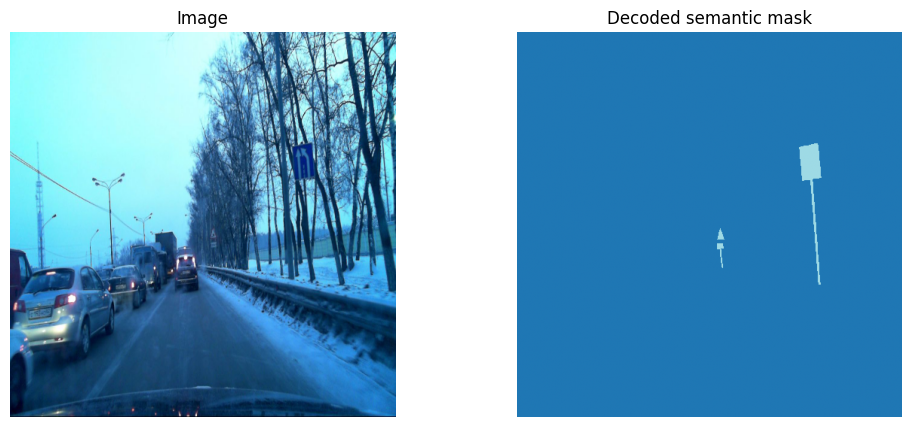

Sample: sign_dataset/train/1.jpg Unique labels: [0 1]


In [27]:
idx = 0
img_t, mask_t, p = train_ds[idx]
img = (img_t.permute(1, 2, 0).numpy() * 255).astype(np.uint8)
mask = mask_t.numpy()

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title('Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(mask, cmap='tab20')
plt.title('Decoded semantic mask')
plt.axis('off')
plt.show()

print('Sample:', p, 'Unique labels:', np.unique(mask))


## 3) Модели и обучение

In [28]:
def _load_partial_weights(model, weight_path: Path, drop_prefixes):
    raw = torch.load(weight_path, map_location='cpu')
    state = raw.get('state_dict', raw) if isinstance(raw, dict) else raw
    model_sd = model.state_dict()
    kept = {}
    dropped_head = 0
    dropped_mismatch = 0
    for k, v in state.items():
        k2 = k.replace('module.', '')
        if any(k2.startswith(pref) for pref in drop_prefixes):
            dropped_head += 1
            continue
        if k2 not in model_sd or model_sd[k2].shape != v.shape:
            dropped_mismatch += 1
            continue
        kept[k2] = v
    msg = model.load_state_dict(kept, strict=False)
    print(f'[INFO] Loaded local weights: {weight_path.name}')
    print(f'[INFO] Loaded tensors: {len(kept)}, dropped_head: {dropped_head}, dropped_mismatch: {dropped_mismatch}')
    print(f'[INFO] Missing keys: {len(msg.missing_keys)}, Unexpected: {len(msg.unexpected_keys)}')
def build_model(name: str, num_classes: int, use_pretrained: bool = True):
    if name == 'deeplabv3_resnet50':
        model = models.segmentation.deeplabv3_resnet50(weights=None, aux_loss=True)
        if use_pretrained:
            local = Path('deeplabv3_resnet50_coco-cd0a2569.pth')
            if local.exists():
                _load_partial_weights(model, local, drop_prefixes=['classifier.4', 'aux_classifier.4'])
            else:
                try:
                    m_pre = models.segmentation.deeplabv3_resnet50(weights='DEFAULT')
                    model.load_state_dict(m_pre.state_dict(), strict=False)
                    print('[INFO] Loaded pretrained from torchvision URL')
                except Exception as e:
                    print(f'[WARN] Pretrained не загружен: {e}')
        in_ch = model.classifier[-1].in_channels
        model.classifier[-1] = nn.Conv2d(in_ch, num_classes, kernel_size=1)
        if model.aux_classifier is not None:
            aux_ch = model.aux_classifier[-1].in_channels
            model.aux_classifier[-1] = nn.Conv2d(aux_ch, num_classes, kernel_size=1)
        return model
    if name == 'lraspp_mobilenet_v3_large':
        model = models.segmentation.lraspp_mobilenet_v3_large(weights=None)
        if use_pretrained:
            local = Path('lraspp_mobilenet_v3_large-d234d4ea.pth')
            if local.exists():
                _load_partial_weights(model, local, drop_prefixes=['classifier.low_classifier', 'classifier.high_classifier'])
            else:
                try:
                    m_pre = models.segmentation.lraspp_mobilenet_v3_large(weights='DEFAULT')
                    model.load_state_dict(m_pre.state_dict(), strict=False)
                    print('[INFO] Loaded pretrained from torchvision URL')
                except Exception as e:
                    print(f'[WARN] Pretrained не загружен: {e}')
        model.classifier.low_classifier = nn.Conv2d(40, num_classes, kernel_size=1)
        model.classifier.high_classifier = nn.Conv2d(128, num_classes, kernel_size=1)
        return model
    raise ValueError(f'Unknown model: {name}')
def soft_dice_loss(logits, targets, num_classes, eps=1e-6):
    probs = F.softmax(logits, dim=1)
    one_hot = F.one_hot(targets, num_classes=num_classes).permute(0, 3, 1, 2).float()
    dims = (0, 2, 3)
    inter = torch.sum(probs * one_hot, dims)
    union = torch.sum(probs + one_hot, dims)
    dice = (2.0 * inter + eps) / (union + eps)
    return 1.0 - dice.mean()
def forward_logits(model, x):
    out = model(x)
    if isinstance(out, dict):
        return out['out']
    return out
@torch.no_grad()
def confusion_stats(pred, target, num_classes):
    tp = torch.zeros(num_classes, device=pred.device)
    fp = torch.zeros(num_classes, device=pred.device)
    fn = torch.zeros(num_classes, device=pred.device)
    for c in range(num_classes):
        p = pred == c
        t = target == c
        tp[c] = (p & t).sum()
        fp[c] = (p & ~t).sum()
        fn[c] = (~p & t).sum()
    return tp, fp, fn
def run_epoch(model, loader, optimizer=None, desc=None, show_pbar=False):
    train = optimizer is not None
    model.train(train)
    ce_loss = nn.CrossEntropyLoss()
    total_loss = 0.0
    tp_all = torch.zeros(NUM_CLASSES, device=device)
    fp_all = torch.zeros(NUM_CLASSES, device=device)
    fn_all = torch.zeros(NUM_CLASSES, device=device)
    l2_vals = []
    if show_pbar and USE_TQDM:
        iter_loader = progress_bar(loader, desc=desc, leave=False, dynamic_ncols=True, mininterval=0.5)
    else:
        iter_loader = loader
    for imgs, masks, _ in iter_loader:
        imgs = imgs.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)
        with torch.set_grad_enabled(train):
            logits = forward_logits(model, imgs)
            loss = ce_loss(logits, masks) + 0.5 * soft_dice_loss(logits, masks, NUM_CLASSES)
            if train:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                optimizer.step()
        total_loss += float(loss.item()) * imgs.size(0)
        pred = logits.argmax(dim=1)
        tp, fp, fn = confusion_stats(pred, masks, NUM_CLASSES)
        tp_all += tp
        fp_all += fp
        fn_all += fn
        p_bin = (pred > 0).float()
        t_bin = (masks > 0).float()
        l2_batch = torch.sqrt(torch.mean((p_bin - t_bin) ** 2, dim=(1, 2)))
        l2_vals.extend(l2_batch.detach().cpu().tolist())
    eps = 1e-9
    precision = (tp_all + eps) / (tp_all + fp_all + eps)
    recall = (tp_all + eps) / (tp_all + fn_all + eps)
    iou = (tp_all + eps) / (tp_all + fp_all + fn_all + eps)
    metrics = {
        'loss': total_loss / len(loader.dataset),
        'precision_macro': float(precision[1:].mean().item()),
        'recall_macro': float(recall[1:].mean().item()),
        'iou_macro': float(iou[1:].mean().item()),
        'l2_mean': float(np.mean(l2_vals)) if l2_vals else 0.0,
        'per_class_iou': iou.detach().cpu().numpy(),
    }
    return metrics
def train_model(model_name: str, epochs=12, lr=1e-4, save_dir=Path('checkpoints'), use_pretrained=True):
    save_dir.mkdir(parents=True, exist_ok=True)
    model = build_model(model_name, NUM_CLASSES, use_pretrained=use_pretrained).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    hist = []
    best_iou = -1.0
    best_path = save_dir / f'{model_name}_best.pt'
    for epoch in range(1, epochs + 1):
        tr = run_epoch(model, train_loader, optimizer=optimizer, desc=f"train e{epoch}/{epochs}", show_pbar=True)
        va = run_epoch(model, val_loader, optimizer=None, show_pbar=False)
        row = {
            'epoch': epoch,
            'train_loss': tr['loss'],
            'val_loss': va['loss'],
            'val_iou_macro': va['iou_macro'],
            'val_precision_macro': va['precision_macro'],
            'val_recall_macro': va['recall_macro'],
            'val_l2_mean': va['l2_mean'],
        }
        hist.append(row)
        if va['iou_macro'] > best_iou:
            best_iou = va['iou_macro']
            torch.save({'model_name': model_name, 'state_dict': model.state_dict()}, best_path)
        print(f"[{model_name}] epoch {epoch:02d}/{epochs} | val_iou={va['iou_macro']:.4f} val_prec={va['precision_macro']:.4f} val_rec={va['recall_macro']:.4f} val_l2={va['l2_mean']:.4f}")
    return pd.DataFrame(hist), best_path


In [29]:
MODELS_TO_TRAIN = ['lraspp_mobilenet_v3_large'] if FAST_MODE else ['deeplabv3_resnet50']
USE_PRETRAINED = False if FAST_MODE else True

all_hist = {}
best_ckpts = {}
for m in MODELS_TO_TRAIN:
    hist_df, best_path = train_model(m, epochs=EPOCHS, lr=LR, use_pretrained=USE_PRETRAINED)
    all_hist[m] = hist_df
    best_ckpts[m] = best_path

print('Best checkpoints:')
for k, v in best_ckpts.items():
    print(k, '->', v)


[INFO] Loaded local weights: deeplabv3_resnet50_coco-cd0a2569.pth
[INFO] Loaded tensors: 366, dropped_head: 4, dropped_mismatch: 0
[INFO] Missing keys: 4, Unexpected: 0


[deeplabv3_resnet50] epoch 01/5 | val_iou=0.5254 val_prec=0.7145 val_rec=0.6650 val_l2=0.0678


[deeplabv3_resnet50] epoch 02/5 | val_iou=0.6138 val_prec=0.8534 val_rec=0.6862 val_l2=0.0553


[deeplabv3_resnet50] epoch 03/5 | val_iou=0.6234 val_prec=0.8662 val_rec=0.6899 val_l2=0.0537


[deeplabv3_resnet50] epoch 04/5 | val_iou=0.6150 val_prec=0.9096 val_rec=0.6551 val_l2=0.0531


[deeplabv3_resnet50] epoch 05/5 | val_iou=0.6822 val_prec=0.8913 val_rec=0.7441 val_l2=0.0489
Best checkpoints:
deeplabv3_resnet50 -> checkpoints/deeplabv3_resnet50_best.pt


In [30]:
# Сводная таблица по последней эпохе
rows = []
for m, df in all_hist.items():
    r = df.iloc[-1].to_dict()
    r['model'] = m
    rows.append(r)
summary_df = pd.DataFrame(rows)[['model', 'train_loss', 'val_loss', 'val_iou_macro', 'val_precision_macro', 'val_recall_macro', 'val_l2_mean']]
summary_df


,model,train_loss,val_loss,val_iou_macro,val_precision_macro,val_recall_macro,val_l2_mean
0,deeplabv3_resnet50,0.054176,0.0789,0.682202,0.891292,0.744117,0.048896


## 4) Финальная оценка на val
Считаем:
- IoU / Precision / Recall / L2;
- процент изображений, где IoU (по всем классам знаков как foreground) >= 0.5 / 0.75 / 0.9.


In [32]:
from tqdm import tqdm


@torch.no_grad()
def evaluate_checkpoint(ckpt_path: Path, dataset: Dataset):
    ckpt = torch.load(ckpt_path, map_location=device)
    model = build_model(ckpt['model_name'], NUM_CLASSES).to(device)
    model.load_state_dict(ckpt['state_dict'])
    model.eval()

    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

    tp_all = torch.zeros(NUM_CLASSES, device=device)
    fp_all = torch.zeros(NUM_CLASSES, device=device)
    fn_all = torch.zeros(NUM_CLASSES, device=device)

    l2_vals = []
    img_iou_vals = []

    for imgs, masks, _ in tqdm(loader):
        imgs = imgs.to(device)
        masks = masks.to(device)

        logits = forward_logits(model, imgs)
        pred = logits.argmax(dim=1)

        tp, fp, fn = confusion_stats(pred, masks, NUM_CLASSES)
        tp_all += tp
        fp_all += fp
        fn_all += fn

        p_bin = (pred > 0).float()
        t_bin = (masks > 0).float()

        # IoU по изображению (foreground)
        inter = (p_bin * t_bin).sum(dim=(1, 2))
        union = ((p_bin + t_bin) > 0).float().sum(dim=(1, 2))
        iou_img = torch.where(union > 0, inter / (union + 1e-9), torch.ones_like(union))
        img_iou_vals.extend(iou_img.detach().cpu().tolist())

        l2_batch = torch.sqrt(torch.mean((p_bin - t_bin) ** 2, dim=(1, 2)))
        l2_vals.extend(l2_batch.detach().cpu().tolist())

    eps = 1e-9
    precision = (tp_all + eps) / (tp_all + fp_all + eps)
    recall = (tp_all + eps) / (tp_all + fn_all + eps)
    iou = (tp_all + eps) / (tp_all + fp_all + fn_all + eps)

    result = {
        'iou_macro': float(iou[1:].mean().item()),
        'precision_macro': float(precision[1:].mean().item()),
        'recall_macro': float(recall[1:].mean().item()),
        'l2_mean': float(np.mean(l2_vals)),
        'pct_iou_ge_0.5': float(np.mean(np.array(img_iou_vals) >= 0.5) * 100),
        'pct_iou_ge_0.75': float(np.mean(np.array(img_iou_vals) >= 0.75) * 100),
        'pct_iou_ge_0.9': float(np.mean(np.array(img_iou_vals) >= 0.9) * 100),
        'per_class_iou': iou.detach().cpu().numpy(),
    }
    return result

final_rows = []
for m, ckpt in best_ckpts.items():
    res = evaluate_checkpoint(ckpt, val_ds)
    final_rows.append({
        'model': m,
        'IoU_macro': res['iou_macro'],
        'Precision_macro': res['precision_macro'],
        'Recall_macro': res['recall_macro'],
        'L2_mean': res['l2_mean'],
        '% IoU>=0.5': res['pct_iou_ge_0.5'],
        '% IoU>=0.75': res['pct_iou_ge_0.75'],
        '% IoU>=0.9': res['pct_iou_ge_0.9'],
    })

final_metrics_df = pd.DataFrame(final_rows)
final_metrics_df


[INFO] Loaded local weights: deeplabv3_resnet50_coco-cd0a2569.pth
[INFO] Loaded tensors: 366, dropped_head: 4, dropped_mismatch: 0
[INFO] Missing keys: 4, Unexpected: 0


100%|██████████| 32/32 [00:11<00:00,  2.67it/s]


,model,IoU_macro,Precision_macro,Recall_macro,L2_mean,% IoU>=0.5,% IoU>=0.75,% IoU>=0.9
0,deeplabv3_resnet50,0.682202,0.891292,0.744117,0.048896,77.952756,29.92126,1.574803


[INFO] Loaded local weights: deeplabv3_resnet50_coco-cd0a2569.pth
[INFO] Loaded tensors: 366, dropped_head: 4, dropped_mismatch: 0
[INFO] Missing keys: 4, Unexpected: 0


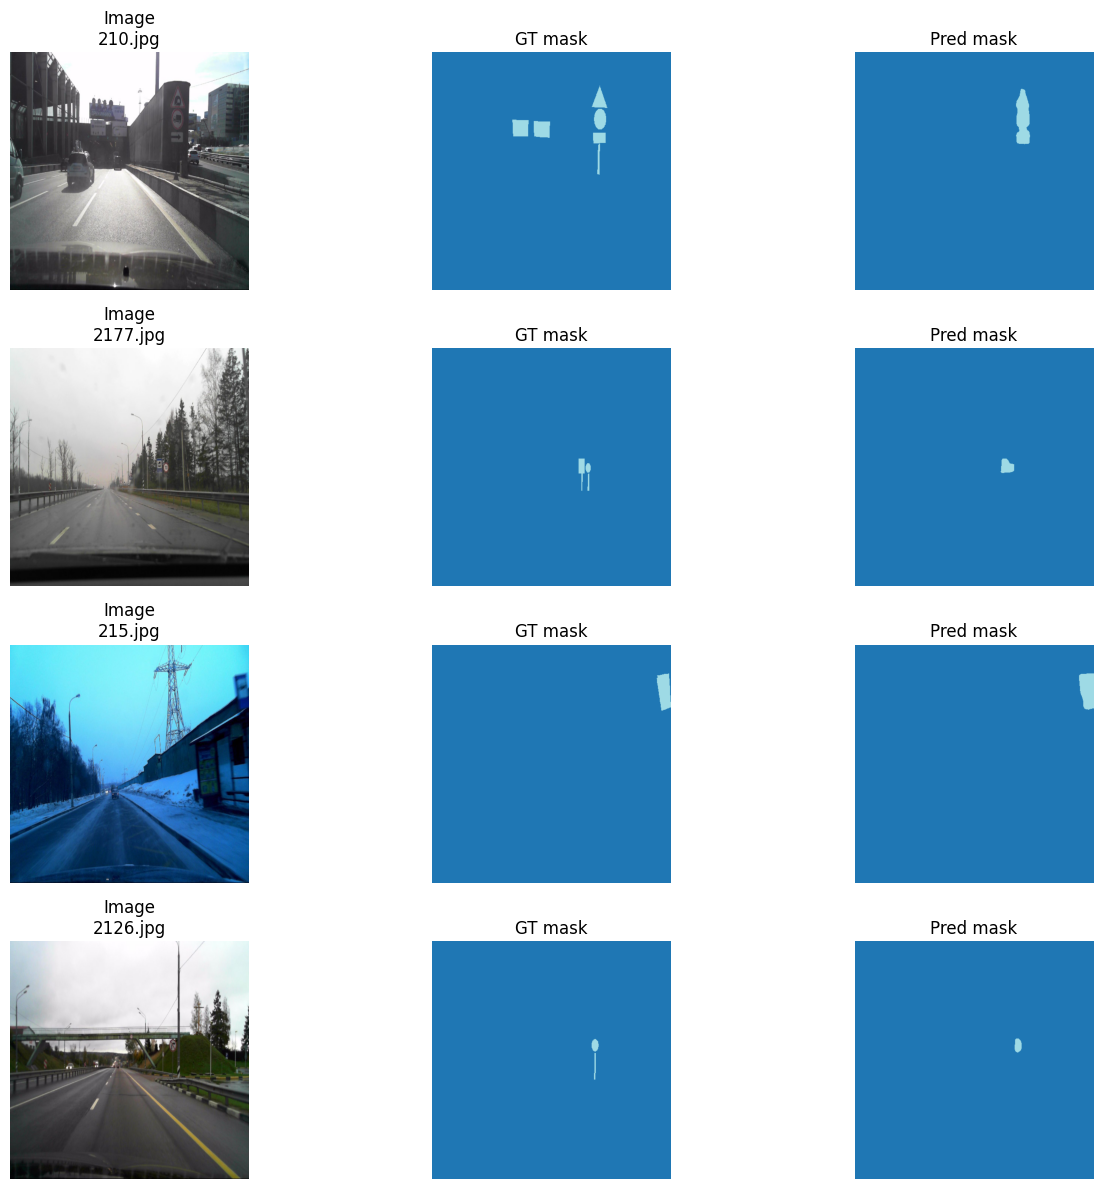

Best model: deeplabv3_resnet50


In [33]:
best_model_name = final_metrics_df.sort_values('IoU_macro', ascending=False).iloc[0]['model']
best_ckpt = best_ckpts[best_model_name]

ckpt = torch.load(best_ckpt, map_location=device)
model = build_model(ckpt['model_name'], NUM_CLASSES).to(device)
model.load_state_dict(ckpt['state_dict'])
model.eval()

def colorize_mask(mask):
    cmap = plt.get_cmap('tab20', NUM_CLASSES)
    colored = (cmap(mask.astype(np.int32))[..., :3] * 255).astype(np.uint8)
    return colored

idxs = np.random.choice(len(val_ds), size=min(4, len(val_ds)), replace=False)
plt.figure(figsize=(14, 3 * len(idxs)))

for row, idx in enumerate(idxs, start=1):
    img_t, gt_t, p = val_ds[idx]
    with torch.no_grad():
        logits = forward_logits(model, img_t.unsqueeze(0).to(device))
        pred = logits.argmax(dim=1).squeeze(0).cpu().numpy()

    img = (img_t.permute(1, 2, 0).numpy() * 255).astype(np.uint8)
    gt = gt_t.numpy()

    plt.subplot(len(idxs), 3, 3*row-2)
    plt.imshow(img)
    plt.title(f'Image\n{Path(p).name}')
    plt.axis('off')

    plt.subplot(len(idxs), 3, 3*row-1)
    plt.imshow(colorize_mask(gt))
    plt.title('GT mask')
    plt.axis('off')

    plt.subplot(len(idxs), 3, 3*row)
    plt.imshow(colorize_mask(pred))
    plt.title('Pred mask')
    plt.axis('off')

plt.tight_layout()
plt.show()
print('Best model:', best_model_name)


## 5) Оценка на своих фотографиях (опционально)

Если добавите фотографии в `my_photos/` и (опционально) разметку тем же форматом `*.jpg_coco.json`,
код ниже построит предсказания и посчитает те же метрики при наличии GT.

In [50]:
MY_PHOTOS_DIR = Path('my_photos')
MY_PHOTOS_OUT = Path('outputs/photos')
MY_PHOTOS_OUT.mkdir(parents=True, exist_ok=True)

SEG_PROB_THR = 0.65
SEG_MIN_AREA = 180
SEG_MORPH_K = 3
SEG_MORPH_ITERS = 1

def denoise_mask(bin_mask: np.ndarray, min_area=180, k=3, iters=1):
    m = (bin_mask > 0).astype(np.uint8)
    kernel = np.ones((k, k), np.uint8)

    m = cv2.morphologyEx(m, cv2.MORPH_OPEN, kernel, iterations=iters)
    m = cv2.morphologyEx(m, cv2.MORPH_CLOSE, kernel, iterations=iters)

    n_labels, labels, stats, _ = cv2.connectedComponentsWithStats(m, connectivity=8)
    out = np.zeros_like(m)
    for i in range(1, n_labels):
        area = stats[i, cv2.CC_STAT_AREA]
        if area >= min_area:
            out[labels == i] = 1
    return out

def predict_image_semantic(model, img_bgr, img_size=(512, 512), prob_thr=0.65, min_area=180):
    rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    h0, w0 = rgb.shape[:2]
    inp = cv2.resize(rgb, img_size[::-1], interpolation=cv2.INTER_LINEAR)
    x = torch.from_numpy(inp).float().permute(2, 0, 1).unsqueeze(0) / 255.0
    x = x.to(device)

    with torch.no_grad():
        logits = forward_logits(model, x)

        # Для бинарной сегментации используем порог по вероятности класса знака
        if logits.shape[1] == 2:
            probs = torch.softmax(logits, dim=1)[:, 1]  # вероятность road_sign
            pred_small = (probs.squeeze(0).cpu().numpy() >= prob_thr).astype(np.uint8)
        else:
            pred_small = logits.argmax(dim=1).squeeze(0).cpu().numpy().astype(np.uint8)

    pred_full = cv2.resize(pred_small, (w0, h0), interpolation=cv2.INTER_NEAREST)

    # Шумоподавление на финальном разрешении
    if logits.shape[1] == 2:
        pred_full = denoise_mask(pred_full, min_area=min_area, k=SEG_MORPH_K, iters=SEG_MORPH_ITERS)

    return pred_full.astype(np.uint8)

if MY_PHOTOS_DIR.exists():
    rows = []
    for img_path in sorted(MY_PHOTOS_DIR.glob('*.jpg')):
        img_bgr = cv2.imread(str(img_path))
        pred = predict_image_semantic(model, img_bgr, IMG_SIZE, prob_thr=SEG_PROB_THR, min_area=SEG_MIN_AREA)

        overlay = img_bgr.copy()
        fg = pred > 0
        overlay[fg] = (0.6 * overlay[fg] + 0.4 * np.array([0, 0, 255])).astype(np.uint8)

        out_path = MY_PHOTOS_OUT / f'{img_path.stem}_overlay.jpg'
        cv2.imwrite(str(out_path), overlay)

        gt_path = Path(str(img_path).replace('.jpg', '_mask.png'))
        if gt_path.exists():
            gt = cv2.imread(str(gt_path), cv2.IMREAD_GRAYSCALE)
            if gt is None:
                continue
            gt = (gt > 0).astype(np.uint8)

            p_bin = pred > 0
            t_bin = gt > 0
            inter = np.logical_and(p_bin, t_bin).sum()
            union = np.logical_or(p_bin, t_bin).sum()
            iou = inter / (union + 1e-9) if union > 0 else 1.0
            l2 = np.sqrt(np.mean((p_bin.astype(np.float32) - t_bin.astype(np.float32)) ** 2))
            rows.append({'image': img_path.name, 'IoU_fg': iou, 'L2_fg': l2})

    if rows:
        my_df = pd.DataFrame(rows)
        display(my_df)
        print('Mean IoU:', my_df['IoU_fg'].mean())
        print('Mean L2 :', my_df['L2_fg'].mean())
    else:
        print('Фото обработаны. GT-разметка не найдена, выведены только оверлеи в outputs/photos')
else:
    print('Папка my_photos не найдена. Создайте ее при необходимости.')


Папка my_photos не найдена. Создайте ее при необходимости.


## 6) Видео: сегментация + 2 трекера

Ниже готовый код для ваших видео (`30+ сек`, `3+ видео`).

Трекеры:
- `IoUTracker`
- `CentroidTracker` (matching по расстоянию между центрами).

Для метрики **ID Switches** добавлен расчет через `motmetrics` при наличии GT-треков
в формате MOTChallenge (`frame,id,x,y,w,h,conf,class,vis`).

In [51]:
def mask_to_detections(semantic_mask, min_area=420, min_side=18, ar_min=0.55, ar_max=1.9, border_margin=4):
    """Из semantic mask -> список детекций: dict(x1,y1,x2,y2,cls,score)."""
    dets = []
    H, W = semantic_mask.shape[:2]
    for cls in range(1, NUM_CLASSES):
        bin_mask = (semantic_mask == cls).astype(np.uint8)
        if bin_mask.sum() == 0:
            continue
        n_labels, labels, stats, _ = cv2.connectedComponentsWithStats(bin_mask, connectivity=8)
        for i in range(1, n_labels):
            x, y, w, h, area = stats[i]
            if area < min_area:
                continue
            if w < min_side or h < min_side:
                continue
            ar = w / max(1.0, float(h))
            if ar < ar_min or ar > ar_max:
                continue
            # Подавляем мусор на границах кадра
            if x <= border_margin or y <= border_margin or (x + w) >= (W - border_margin) or (y + h) >= (H - border_margin):
                continue
            comp = (labels == i).astype(np.uint8)
            fill = float(area) / max(1.0, float(w * h))
            if fill < 0.28:
                continue
            dets.append({
                'bbox': [int(x), int(y), int(x + w), int(y + h)],
                'cls': int(cls),
                'score': float(min(1.0, area / (area + 500.0)))
            })
    return dets
def bbox_iou_xyxy(a, b):
    ax1, ay1, ax2, ay2 = a
    bx1, by1, bx2, by2 = b
    ix1, iy1 = max(ax1, bx1), max(ay1, by1)
    ix2, iy2 = min(ax2, bx2), min(ay2, by2)
    iw, ih = max(0, ix2 - ix1), max(0, iy2 - iy1)
    inter = iw * ih
    area_a = max(0, ax2 - ax1) * max(0, ay2 - ay1)
    area_b = max(0, bx2 - bx1) * max(0, by2 - by1)
    union = area_a + area_b - inter
    return inter / (union + 1e-9)
class IoUTracker:
    def __init__(self, iou_thr=0.3, max_age=20):
        self.iou_thr = iou_thr
        self.max_age = max_age
        self.tracks = {}
        self.next_id = 1
    def update(self, detections):
        # detections: list of dict with bbox
        assigned = set()
        updates = {}
        for tid, tr in list(self.tracks.items()):
            best_j, best_iou = -1, 0.0
            for j, d in enumerate(detections):
                if j in assigned:
                    continue
                iou = bbox_iou_xyxy(tr['bbox'], d['bbox'])
                if iou > best_iou:
                    best_iou, best_j = iou, j
            if best_j >= 0 and best_iou >= self.iou_thr:
                d = detections[best_j]
                assigned.add(best_j)
                updates[tid] = {'bbox': d['bbox'], 'age': 0, 'cls': d['cls']}
            else:
                tr['age'] += 1
                if tr['age'] <= self.max_age:
                    updates[tid] = tr
        for j, d in enumerate(detections):
            if j in assigned:
                continue
            updates[self.next_id] = {'bbox': d['bbox'], 'age': 0, 'cls': d['cls']}
            self.next_id += 1
        self.tracks = updates
        out = []
        for tid, tr in self.tracks.items():
            out.append({'track_id': tid, 'bbox': tr['bbox'], 'cls': tr['cls']})
        return out
class CentroidTracker:
    def __init__(self, dist_thr=80.0, max_age=20):
        self.dist_thr = dist_thr
        self.max_age = max_age
        self.tracks = {}
        self.next_id = 1
    def _center(self, b):
        x1,y1,x2,y2 = b
        return np.array([(x1+x2)/2.0, (y1+y2)/2.0], dtype=np.float32)
    def update(self, detections):
        assigned = set()
        updates = {}
        for tid, tr in list(self.tracks.items()):
            c_prev = self._center(tr['bbox'])
            best_j, best_dist = -1, 1e9
            for j, d in enumerate(detections):
                if j in assigned:
                    continue
                c_now = self._center(d['bbox'])
                dist = float(np.linalg.norm(c_prev - c_now))
                if dist < best_dist:
                    best_dist, best_j = dist, j
            if best_j >= 0 and best_dist <= self.dist_thr:
                d = detections[best_j]
                assigned.add(best_j)
                updates[tid] = {'bbox': d['bbox'], 'age': 0, 'cls': d['cls']}
            else:
                tr['age'] += 1
                if tr['age'] <= self.max_age:
                    updates[tid] = tr
        for j, d in enumerate(detections):
            if j in assigned:
                continue
            updates[self.next_id] = {'bbox': d['bbox'], 'age': 0, 'cls': d['cls']}
            self.next_id += 1
        self.tracks = updates
        out = []
        for tid, tr in self.tracks.items():
            out.append({'track_id': tid, 'bbox': tr['bbox'], 'cls': tr['cls']})
        return out
def draw_tracks(frame_bgr, tracks, name='tracker'):
    vis = frame_bgr.copy()
    for t in tracks:
        x1,y1,x2,y2 = map(int, t['bbox'])
        tid = t['track_id']
        cls = t['cls']
        cv2.rectangle(vis, (x1,y1), (x2,y2), (0,255,0), 2)
        cv2.putText(vis, f'{name} id={tid} c={cls}', (x1, max(0,y1-6)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 1, cv2.LINE_AA)
    return vis


In [62]:
import time
VIDEOS_DIR = Path('videos')
VIDEO_OUTPUT_DIR = Path('outputs/videos')
VIDEO_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
# Параметры для видео (антишум)
VIDEO_SEG_PROB_THR = 0.78
VIDEO_SEG_MIN_AREA = 320
DET_MIN_AREA = 420
DET_MIN_SIDE = 18
DET_AR_MIN = 0.55
DET_AR_MAX = 1.9
DET_BORDER_MARGIN = 4
video_paths = sorted(VIDEOS_DIR.glob('*.mp4'))
if not video_paths:
    video_paths = sorted(Path('.').glob('*.mp4'))
print('Found videos:', [p.name for p in video_paths])
def _line_progress(prefix, i, n, width=26):
    if n <= 0:
        print(f'\r{prefix}: {i} frames', end='', flush=True)
        return
    frac = min(1.0, i / n)
    filled = int(width * frac)
    bar = '#' * filled + '-' * (width - filled)
    print(f'\r{prefix} [{bar}] {i}/{n} ({frac*100:5.1f}%)', end='', flush=True)
def run_video_pipeline(video_path: Path, model, out_dir: Path):
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise RuntimeError(f'Cannot open video: {video_path}')
    fps = cap.get(cv2.CAP_PROP_FPS) or 25.0
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    out_iou = cv2.VideoWriter(str(out_dir / f'{video_path.stem}_iou_tracker.mp4'),
                             cv2.VideoWriter_fourcc(*'mp4v'), fps, (w, h))
    out_ctr = cv2.VideoWriter(str(out_dir / f'{video_path.stem}_centroid_tracker.mp4'),
                             cv2.VideoWriter_fourcc(*'mp4v'), fps, (w, h))
    iou_tracker = IoUTracker(iou_thr=0.35, max_age=12)
    ctr_tracker = CentroidTracker(dist_thr=70.0, max_age=12)
    mot_iou_lines = []
    mot_ctr_lines = []
    frame_id = 0
    t0 = time.time()
    prefix = f'frames {video_path.name}'
    while True:
        ok, frame = cap.read()
        if not ok:
            break
        frame_id += 1
        sem = predict_image_semantic(
            model, frame, IMG_SIZE,
            prob_thr=VIDEO_SEG_PROB_THR,
            min_area=VIDEO_SEG_MIN_AREA
        )
        try:
            dets = mask_to_detections(
                sem,
                min_area=DET_MIN_AREA,
                min_side=DET_MIN_SIDE,
                ar_min=DET_AR_MIN,
                ar_max=DET_AR_MAX,
                border_margin=DET_BORDER_MARGIN
            )
        except TypeError:
            # fallback: в памяти может быть старая версия функции (без новых аргументов)
            dets = mask_to_detections(sem, min_area=DET_MIN_AREA)
        tr_iou = iou_tracker.update(dets)
        tr_ctr = ctr_tracker.update(dets)
        vis_iou = draw_tracks(frame, tr_iou, name='IoU')
        vis_ctr = draw_tracks(frame, tr_ctr, name='Centroid')
        out_iou.write(vis_iou)
        out_ctr.write(vis_ctr)
        for t in tr_iou:
            x1, y1, x2, y2 = t['bbox']
            w_box, h_box = x2 - x1, y2 - y1
            mot_iou_lines.append(f"{frame_id},{t['track_id']},{x1},{y1},{w_box},{h_box},1,{t['cls']},1")
        for t in tr_ctr:
            x1, y1, x2, y2 = t['bbox']
            w_box, h_box = x2 - x1, y2 - y1
            mot_ctr_lines.append(f"{frame_id},{t['track_id']},{x1},{y1},{w_box},{h_box},1,{t['cls']},1")
        if frame_id % 5 == 0 or (total_frames > 0 and frame_id == total_frames):
            _line_progress(prefix, frame_id, total_frames)
    _line_progress(prefix, frame_id, total_frames)
    dt = time.time() - t0
    fps_eff = frame_id / max(dt, 1e-9)
    print(f' | {fps_eff:.2f} FPS')
    cap.release()
    out_iou.release()
    out_ctr.release()
    (out_dir / f'{video_path.stem}_iou_tracker.txt').write_text('\n'.join(mot_iou_lines))
    (out_dir / f'{video_path.stem}_centroid_tracker.txt').write_text('\n'.join(mot_ctr_lines))
    return {
        'video': video_path.name,
        'frames': frame_id,
        'iou_video': str(out_dir / f'{video_path.stem}_iou_tracker.mp4'),
        'centroid_video': str(out_dir / f'{video_path.stem}_centroid_tracker.mp4'),
        'iou_mot': str(out_dir / f'{video_path.stem}_iou_tracker.txt'),
        'centroid_mot': str(out_dir / f'{video_path.stem}_centroid_tracker.txt')
    }
video_runs = []
if video_paths:
    total_videos = len(video_paths)
    for vi, vp in enumerate(video_paths, start=1):
        print(f'\n[video {vi}/{total_videos}] {vp.name}')
        r = run_video_pipeline(vp, model, VIDEO_OUTPUT_DIR)
        video_runs.append(r)
else:
    print('Нет видео в папке videos/')
pd.DataFrame(video_runs) if video_runs else None


Found videos: ['first.mp4', 'second.mp4', 'third.mp4']

[video 1/3] first.mp4
frames first.mp4 [#########################-] 2199/2200 (100.0%) | 10.22 FPS

[video 2/3] second.mp4
frames second.mp4 [#########################-] 2158/2174 ( 99.3%) | 10.56 FPS

[video 3/3] third.mp4
frames third.mp4 [#########################-] 2106/2115 ( 99.6%) | 10.47 FPS


,video,frames,iou_video,centroid_video,iou_mot,centroid_mot
0,first.mp4,2199,outputs/videos/first_iou_tracker.mp4,outputs/videos/first_centroid_tracker.mp4,outputs/videos/first_iou_tracker.txt,outputs/videos/first_centroid_tracker.txt
1,second.mp4,2158,outputs/videos/second_iou_tracker.mp4,outputs/videos/second_centroid_tracker.mp4,outputs/videos/second_iou_tracker.txt,outputs/videos/second_centroid_tracker.txt
2,third.mp4,2106,outputs/videos/third_iou_tracker.mp4,outputs/videos/third_centroid_tracker.mp4,outputs/videos/third_iou_tracker.txt,outputs/videos/third_centroid_tracker.txt


## 7) Визуализация Кадров С Распознанными Знаками

Этот блок показывает несколько кадров из каждого видео с распознанными дорожными знаками:
- красная маска = сегментация знаков;
- зеленые прямоугольники = детекции после фильтрации.


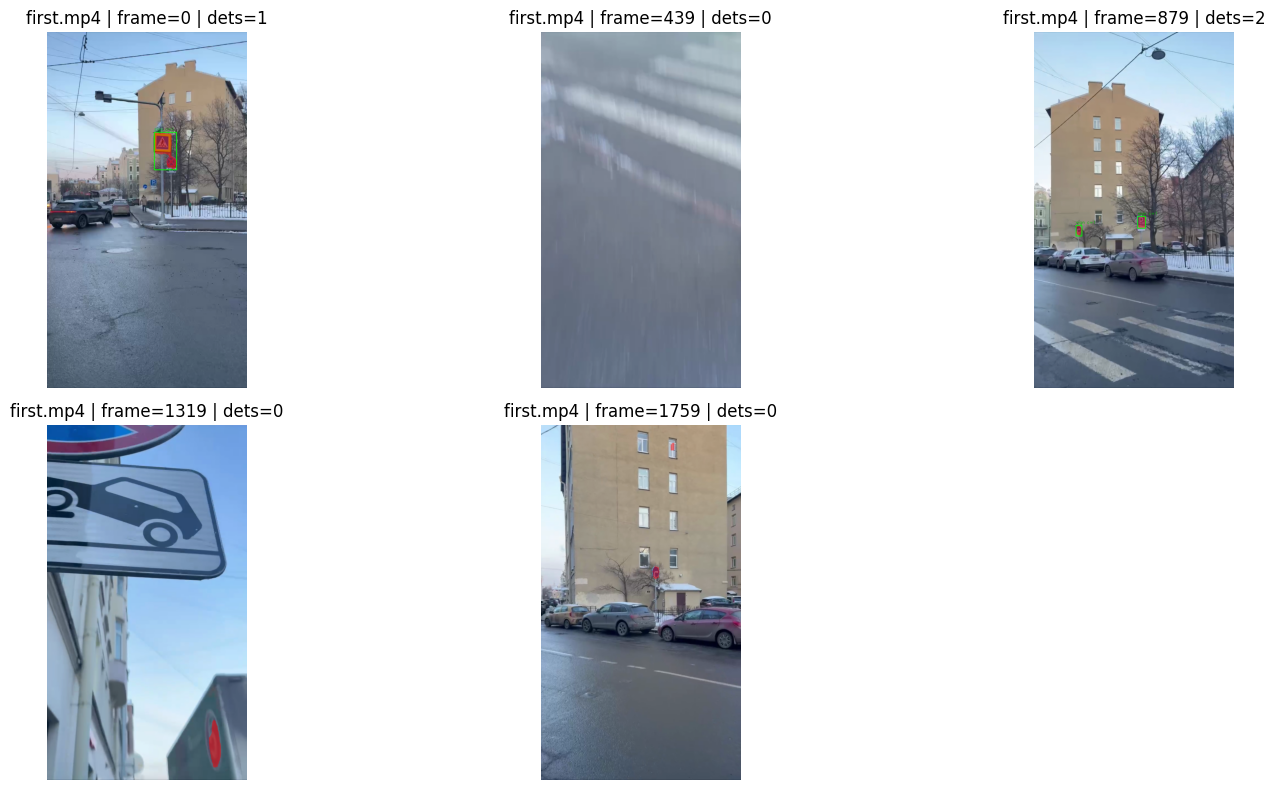

Кадры сохранены в: /Users/egorzukov/Documents/comp_vision/lab3/outputs/video_frames


In [60]:
# Параметры визуализации
N_FRAMES_PER_VIDEO = 6
DRAW_MASK = True
WHITE_BACKGROUND = False
SAVE_FRAMES = True
FRAMES_OUT_DIR = Path('outputs/video_frames')
FRAMES_OUT_DIR.mkdir(parents=True, exist_ok=True)
MASK_COLOR = np.array([255, 0, 0], dtype=np.uint8)  # RGB: красный
def draw_detections_rgb(img_rgb, dets):
    vis = img_rgb.copy()
    for d in dets:
        x1, y1, x2, y2 = map(int, d['bbox'])
        cls = int(d.get('cls', 1))
        cv2.rectangle(vis, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(vis, f'sign c={cls}', (x1, max(0, y1 - 6)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 180, 0), 1, cv2.LINE_AA)
    return vis
def apply_mask_on_white(frame_bgr, sem_mask):
    # Оставляем фото видимым, но осветляем его к белому фону
    img = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
    base = (0.72 * img + 0.28 * 255).astype(np.uint8)
    if DRAW_MASK:
        fg = sem_mask > 0
        base[fg] = (0.35 * base[fg] + 0.65 * MASK_COLOR).astype(np.uint8)
        # Контур маски для лучшей видимости
        cnts, _ = cv2.findContours((sem_mask > 0).astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        cv2.drawContours(base, cnts, -1, (160, 0, 0), 2)
    return base
def sample_frame_indices(total_frames, n):
    if total_frames <= 0:
        return []
    n = min(n, total_frames)
    return np.linspace(0, total_frames - 1, n, dtype=int).tolist()
def show_video_predictions(video_path: Path, n_frames=6):
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        print(f'Cannot open: {video_path}')
        return
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    idxs = set(sample_frame_indices(total_frames, n_frames))
    selected = []
    i = 0
    while True:
        ok, frame = cap.read()
        if not ok:
            break
        if i in idxs:
            sem = predict_image_semantic(
                model, frame, IMG_SIZE,
                prob_thr=VIDEO_SEG_PROB_THR if 'VIDEO_SEG_PROB_THR' in globals() else SEG_PROB_THR,
                min_area=VIDEO_SEG_MIN_AREA if 'VIDEO_SEG_MIN_AREA' in globals() else SEG_MIN_AREA
            )
            dets = mask_to_detections(
                sem,
                min_area=DET_MIN_AREA if 'DET_MIN_AREA' in globals() else 180,
                min_side=DET_MIN_SIDE if 'DET_MIN_SIDE' in globals() else 12,
                ar_min=DET_AR_MIN if 'DET_AR_MIN' in globals() else 0.4,
                ar_max=DET_AR_MAX if 'DET_AR_MAX' in globals() else 2.2,
                border_margin=DET_BORDER_MARGIN if 'DET_BORDER_MARGIN' in globals() else 2
            )
            if WHITE_BACKGROUND:
                vis = apply_mask_on_white(frame, sem)
            else:
                vis = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                if DRAW_MASK:
                    fg = sem > 0
                    vis[fg] = (0.5 * vis[fg] + 0.5 * MASK_COLOR).astype(np.uint8)
            vis = draw_detections_rgb(vis, dets)
            selected.append((i, vis, len(dets)))
            if SAVE_FRAMES:
                out_path = FRAMES_OUT_DIR / f'{video_path.stem}_frame_{i:05d}.png'
                cv2.imwrite(str(out_path), cv2.cvtColor(vis, cv2.COLOR_RGB2BGR))
        i += 1
    cap.release()
    if not selected:
        print(f'Нет выбранных кадров: {video_path.name}')
        return
    cols = 3
    rows = int(np.ceil(len(selected) / cols))
    fig = plt.figure(figsize=(16, 4 * rows), facecolor='white')
    for k, (fid, vis, nd) in enumerate(selected, start=1):
        ax = plt.subplot(rows, cols, k)
        ax.set_facecolor('white')
        plt.imshow(vis)
        plt.title(f'{video_path.name} | frame={fid} | dets={nd}')
        plt.axis('off')
    plt.tight_layout()
    plt.show()
# Запуск визуализации по всем видео
vis_video_paths = sorted(Path('videos').glob('*.mp4'))
if not vis_video_paths:
    vis_video_paths = sorted(Path('.').glob('*.mp4'))
if not vis_video_paths:
    print('Видео не найдены (ни в videos/, ни в корне проекта).')
else:
    vp = vis_video_paths[0]
    show_video_predictions(vp, n_frames=N_FRAMES_PER_VIDEO)
if SAVE_FRAMES:
    print(f'Кадры сохранены в: {FRAMES_OUT_DIR.resolve()}')
